In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split


In [8]:
df = pd.read_csv('car_price_dataset.csv', sep=";")
df = df.dropna()
audionly = df[df['Brand'] == "Audi"]
print(audionly)






     Brand Model  Year  Engine_Size Fuel_Type    Transmission  Mileage  Doors  \
3     Audi    Q5  2023          2.0  Electric          Manual   160971      2   
26    Audi    A3  2022          3.3  Electric          Manual    79350      5   
36    Audi    Q5  2013          3.5    Hybrid  Semi-Automatic   263411      4   
39    Audi    A4  2004          1.0    Petrol          Manual    94415      2   
44    Audi    Q5  2023          3.6  Electric          Manual   238306      5   
...    ...   ...   ...          ...       ...             ...      ...    ...   
9961  Audi    A4  2020          3.9    Petrol          Manual    91415      5   
9968  Audi    A3  2006          2.5    Petrol  Semi-Automatic   155630      2   
9985  Audi    A4  2003          1.4    Hybrid       Automatic   173657      4   
9986  Audi    A4  2005          3.6    Petrol  Semi-Automatic   241546      4   
9990  Audi    A3  2019          1.8  Electric          Manual    85496      4   

      Owner_Count  Price  


In [9]:
X = audionly['Mileage']
print(X)


3       160971
26       79350
36      263411
39       94415
44      238306
         ...  
9961     91415
9968    155630
9985    173657
9986    241546
9990     85496
Name: Mileage, Length: 1038, dtype: int64


In [10]:
y = audionly['Price']
print(y)

3       11780
26      14413
36       7231
39       4411
44      11833
        ...  
9961    12171
9968     5287
9985     5426
9986     4369
9990    11890
Name: Price, Length: 1038, dtype: int64


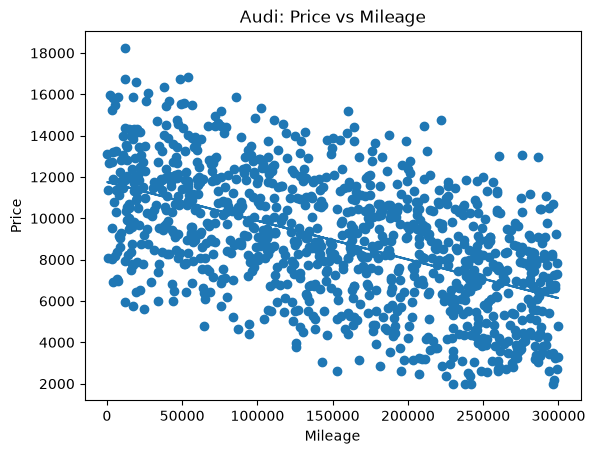

In [11]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = audionly[['Mileage']]
y = audionly['Price']

model = LinearRegression()
model.fit(X, y)

plt.scatter(X, y)

plt.plot(
    X,
    model.predict(X)
)

plt.xlabel('Mileage')
plt.ylabel('Price')
plt.title('Audi: Price vs Mileage')

plt.show()

In [25]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full,y_train_full, test_size=0.25, random_state=42)

param_grid = {
  'max_depth': [1, 3, 5, 10, None]
}

grid = GridSearchCV(
  RandomForestRegressor(random_state=42),
  param_grid,
  cv=5,
  scoring=('neg_root_mean_squared_error')
)

LinModel = LinearRegression()



LinModel.fit(X_train, y_train)
grid.fit(X_train, y_train)


lin_pred = LinModel.predict(X_val)
grid_pred = grid.predict(X_val)

LINRMSE = root_mean_squared_error(y_val, lin_pred)
LINMAE = mean_absolute_error(y_val, lin_pred)
RFRMSE = root_mean_squared_error(y_val, grid_pred)
RFRMAE = mean_absolute_error(y_val, grid_pred)

print(LINRMSE, LINMAE)
print(RFRMSE, RFRMAE)

print("Best params:", grid.best_params_)

grid.cv_results_

2750.1375860372846 2294.194266081352
2774.7512580451044 2302.047054319654
Best params: {'max_depth': 3}


{'mean_fit_time': array([0.16955237, 0.17371349, 0.19318089, 0.19935684, 0.27025771]),
 'std_fit_time': array([0.00685216, 0.0065801 , 0.01578223, 0.00312675, 0.02046551]),
 'mean_score_time': array([0.01477594, 0.01493082, 0.02012644, 0.01771765, 0.02357149]),
 'std_score_time': array([0.00063488, 0.00073183, 0.0065219 , 0.00086501, 0.00442213]),
 'param_max_depth': masked_array(data=[1, 3, 5, 10, None],
              mask=[False, False, False, False, False],
        fill_value=np.str_('?'),
             dtype=object),
 'params': [{'max_depth': 1},
  {'max_depth': 3},
  {'max_depth': 5},
  {'max_depth': 10},
  {'max_depth': None}],
 'split0_test_score': array([-2934.03209845, -2883.91770166, -2942.08695793, -3319.76225532,
        -3602.83595769]),
 'split1_test_score': array([-2473.3099751 , -2460.81997975, -2564.51792462, -2967.76734569,
        -3331.57641579]),
 'split2_test_score': array([-2678.36717796, -2582.07385321, -2644.16010971, -2851.14888618,
        -3026.14903814]),
 '

In [ ]:
import numpy as np
x_antonio = np.array(1000).reshape(-1, 1)
model.predict(x_antonio)

c:\Users\valde\repos\python\pythonml\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([11777.97292987])

In [14]:
from sklearn.datasets import make_classification